# Setup

In [4]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("amerzishminha/forest-fire-smoke-and-non-fire-image-dataset")

dataset_root = os.path.join(path, 'FOREST_FIRE_SMOKE_AND_NON_FIRE_DATASET')

train_dir = os.path.join(dataset_root, 'train')
test_dir = os.path.join(dataset_root, 'test')

if os.path.exists(train_dir):
    print("✅ found 'train' directory")
    print("folders:", os.listdir(train_dir))
else:
    print("❌ failed")

✅ found 'train' directory
folders: ['Smoke', 'non fire', 'fire']


# Data Distribution

--- Train ---
      Class  Count
0     Smoke  10800
1  non fire  10800
2      fire  10800

--- Test ---
      Class  Count
0     Smoke   3500
1  non fire   3500
2      fire   3500


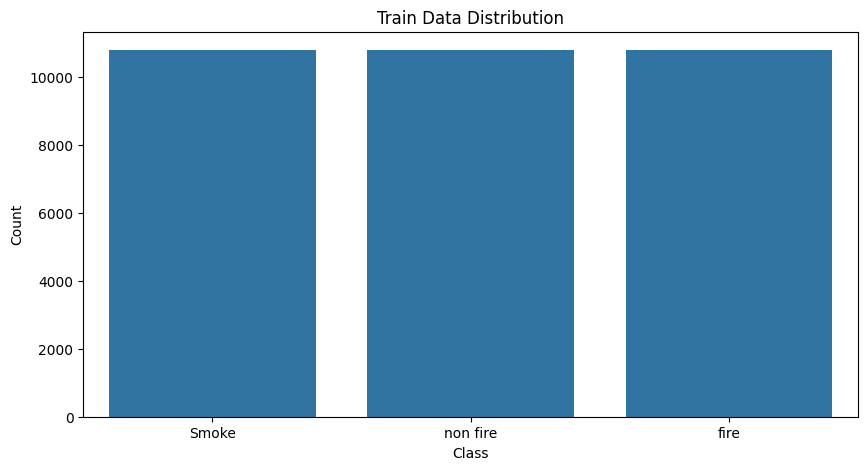

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# count images
def count_images(directory):
    data = []
    for label in os.listdir(directory):
        label_path = os.path.join(directory, label)
        if os.path.isdir(label_path):
            count = len(os.listdir(label_path))
            data.append({'Class': label, 'Count': count})
    return pd.DataFrame(data)

# count Train/Test 
train_counts = count_images(train_dir)
test_counts = count_images(test_dir)

# print
print("--- Train ---")
print(train_counts)
print("\n--- Test ---")
print(test_counts)

# visualization (barplot)
plt.figure(figsize=(10, 5))
sns.barplot(data=train_counts, x='Class', y='Count')
plt.title('Train Data Distribution')
plt.show()

# Visual Grid

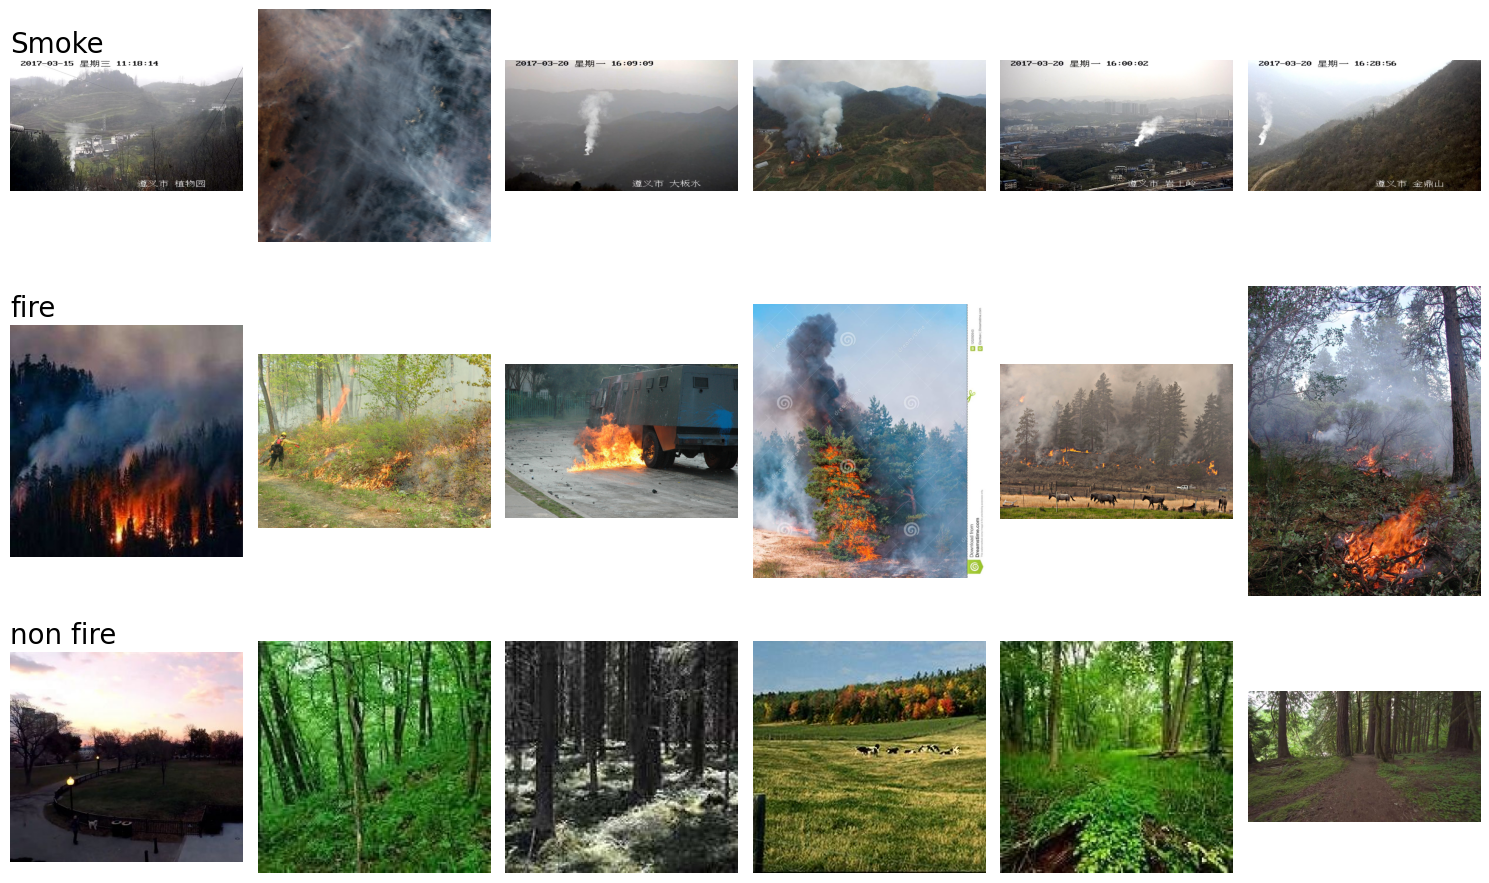

In [6]:
import matplotlib.pyplot as plt
import cv2
import random

os.makedirs('../reports/figures', exist_ok=True)

def show_samples(directory, classes, n_samples=6):
    fig, axes = plt.subplots(len(classes), n_samples, figsize=(15, 10))
    
    for i, label in enumerate(classes):
        label_path = os.path.join(directory, label)

        sample_files = random.sample(os.listdir(label_path), n_samples)
        
        for j, file_name in enumerate(sample_files):
            img_path = os.path.join(label_path, file_name)

            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_title(label, fontsize=20, loc='left')

    plt.tight_layout()

    plt.savefig('../reports/figures/01_sample_grid.png')
    plt.show()


classes = ['Smoke', 'fire', 'non fire']
show_samples(train_dir, classes)

# Dimension Analysis

Checking non fire dimensions: 100%|██████████| 100/100 [00:00<00:00, 6116.64it/s]


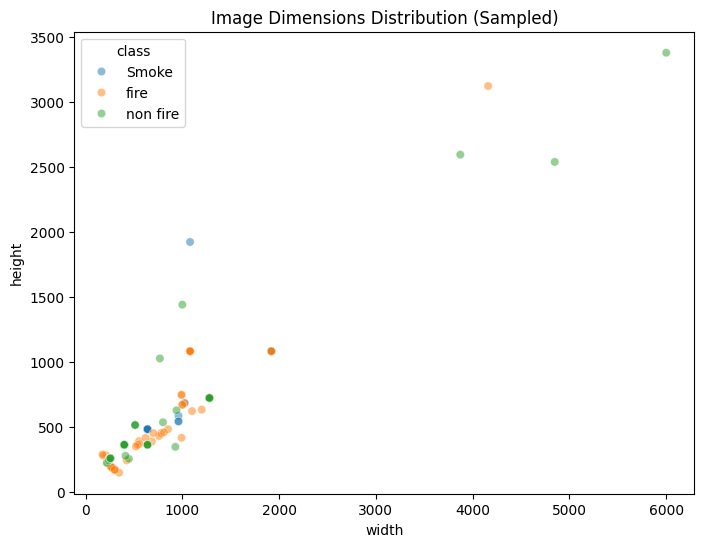

          width                                                             \
          count     mean         std    min    25%     50%     75%     max   
class                                                                        
Smoke     100.0  1474.78  669.808711  256.0  640.0  1920.0  1920.0  1920.0   
fire      100.0   572.01  558.527836  176.0  250.0   264.0   820.5  4160.0   
non fire  100.0   576.66  844.296446  220.0  250.0   256.0   464.0  6000.0   

         height                                                            
          count    mean         std    min    25%     50%     75%     max  
class                                                                      
Smoke     100.0  870.29  350.999879  179.0  480.0  1080.0  1080.0  1920.0  
fire      100.0  428.16  386.665223  145.0  250.0   256.0   451.5  3120.0  
non fire  100.0  432.91  471.800122  220.0  250.0   256.0   360.0  3376.0  


In [7]:
from PIL import Image
from tqdm import tqdm

dims = []
for label in classes:
    label_path = os.path.join(train_dir, label)
    files = os.listdir(label_path)[:100] # 100 images per each class
    
    for f in tqdm(files, desc=f"Checking {label} dimensions"):
        img_path = os.path.join(label_path, f)
        try:
            with Image.open(img_path) as img:
                w, h = img.size
                dims.append({'width': w, 'height': h, 'class': label})
        except:
            print(f"Broken file found: {f}")

df_dims = pd.DataFrame(dims)

# result visualization
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_dims, x='width', y='height', hue='class', alpha=0.5)
plt.title('Image Dimensions Distribution (Sampled)')
plt.savefig('../reports/figures/02_dimensions.png')
plt.show()

# summary
print(df_dims.groupby('class').describe())

# Brighteness and RGB

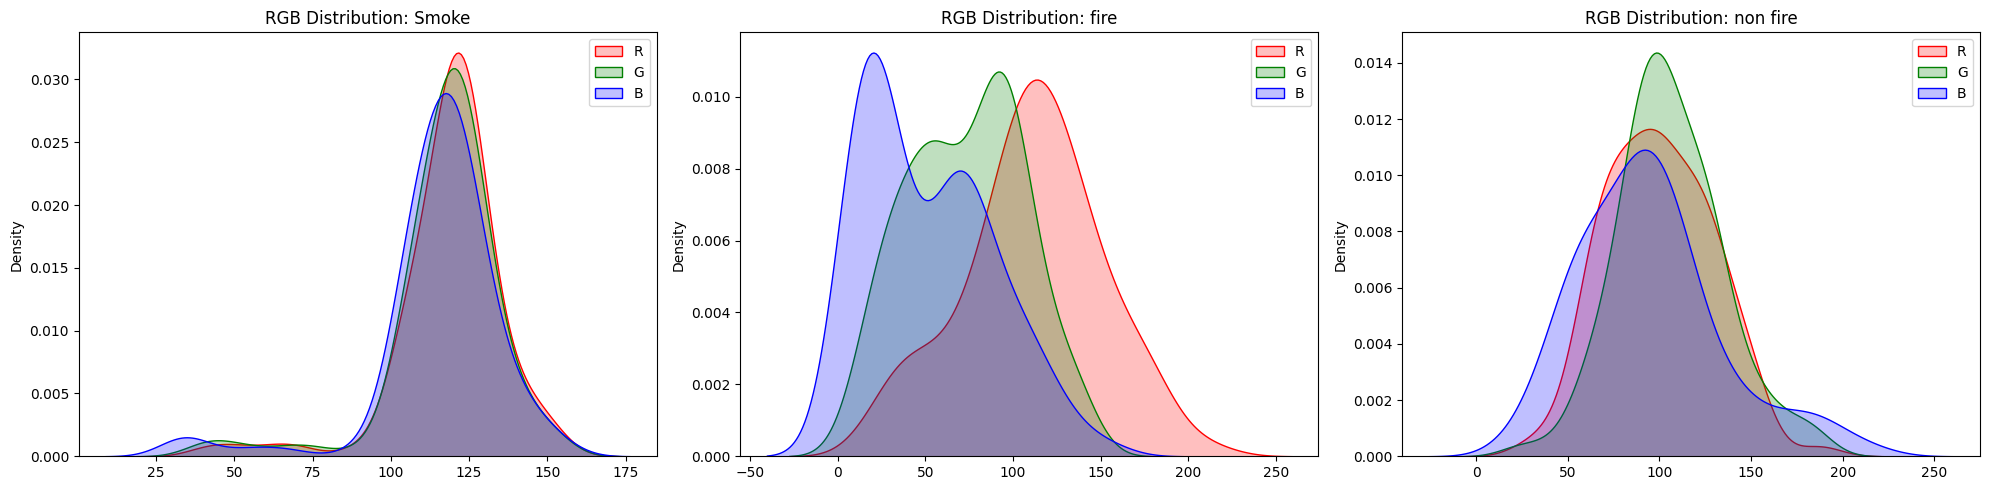

In [ ]:
import numpy as np

def plot_rgb_distribution(directory, classes, n_samples=100):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    colors = ('r', 'g', 'b')
    
    for i, label in enumerate(classes):
        label_path = os.path.join(directory, label)
        sample_files = random.sample(os.listdir(label_path), n_samples)
    
        ch_means = {0: [], 1: [], 2: []}
        
        for file_name in sample_files:
            img = cv2.imread(os.path.join(label_path, file_name))
            if img is None: continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            for j in range(3): # calculation average by R, G, and B channels
                ch_means[j].append(np.mean(img[:, :, j]))
        
        # drawing histogram
        for j, col in enumerate(colors):
            sns.kdeplot(ch_means[j], ax=axes[i], color=col, fill=True, label=col.upper())
        
        axes[i].set_title(f"RGB Distribution: {label}")
        axes[i].legend()

    plt.tight_layout()
    plt.savefig('../reports/figures/03_rgb_distribution.png')
    plt.show()

# execution
plot_rgb_distribution(train_dir, classes)

# Brightness and ambiguous

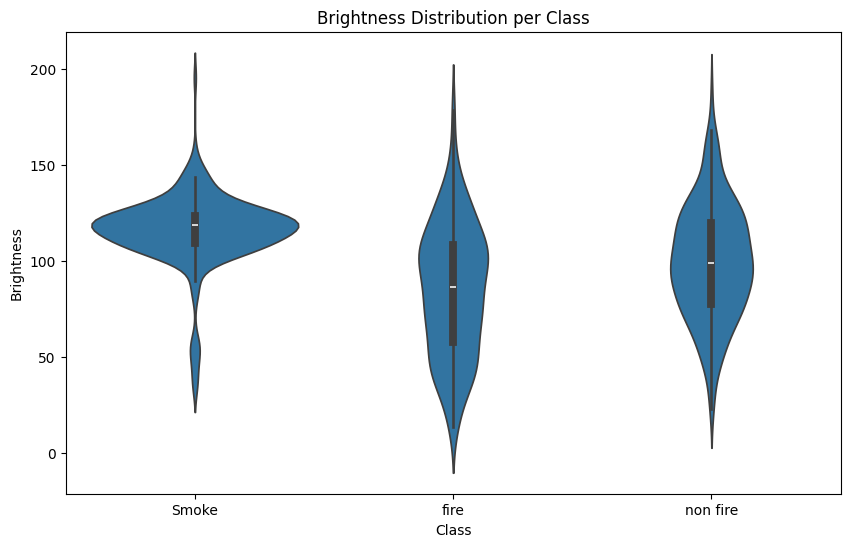

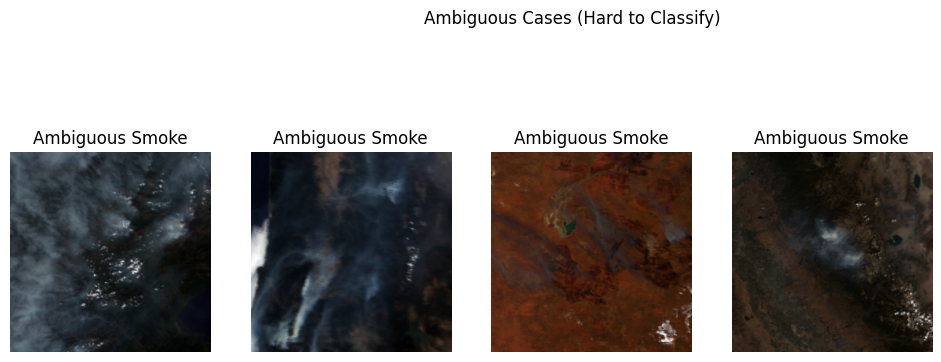

In [9]:
def plot_brightness_and_ambiguous(directory, classes):
    brightness_data = []
    ambiguous_samples = []

    for label in classes:
        label_path = os.path.join(directory, label)
        files = random.sample(os.listdir(label_path), 200) # sampling 200 images
        
        for f in files:
            img = cv2.imread(os.path.join(label_path, f))
            if img is None: continue
            
            # Brightness calculation (average value after grayscale conversion)
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            avg_brightness = np.mean(gray)
            brightness_data.append({'Class': label, 'Brightness': avg_brightness})
            
            # Save cases of Smoke where brightness is too low (dark smoke)
            # Cases of Non-fire where brightness is too high (foggy forest) as 'Ambiguous cases'
            if label == 'Smoke' and (avg_brightness < 50 or avg_brightness > 200):
                ambiguous_samples.append((img, label, f))

    # 1. Visualization of brightness distribution
    plt.figure(figsize=(10, 6))
    sns.violinplot(data=pd.DataFrame(brightness_data), x='Class', y='Brightness')
    plt.title('Brightness Distribution per Class')
    plt.savefig('../reports/figures/04_brightness_distribution.png')
    plt.show()

    # 2. Output ambiguous cases (max. 5)
    if ambiguous_samples:
        plt.figure(figsize=(15, 5))
        for i, (img, label, name) in enumerate(ambiguous_samples[:5]):
            plt.subplot(1, 5, i+1)
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.title(f"Ambiguous {label}")
            plt.axis('off')
        plt.suptitle("Ambiguous Cases (Hard to Classify)")
        plt.savefig('../reports/figures/05_ambiguous_cases.png')
        plt.show()

plot_brightness_and_ambiguous(train_dir, classes)